the Kotlin Notebook plug-in comes packaged with intelliJ ultimate by default, so you should just see notebook as an available file type like this, so we can just create one as we would any other file.

The extension .ipynb stands for IPython Notebook, but today it’s the standard file format for Jupyter notebooks, regardless of language.

And a Jupyter Notebook? It’s an interactive document where you can write code, mark down text, equations, and visualisations together. It allows you to run the code step-by-step and see your results immediately.

In [1]:
// At the top here I have some dependencies, Dataframe is an abstraction for working with structured data, and Kandy is a plotting library.

%useLatestDescriptors
%use dataframe, kandy

Now defining it like this with `useLatestDescriptors` means that we get the latest versions of everything, but we can also set a version number like this.


In [ ]:
// %use dataframe(1.0.0-Beta4n), kandy(0.8.3)

So this `use` notation is called cell magic which gives you access to a lot  of neat functionality, but sometimes the thing you need isn’t available, so you also have the option of this file:DependsOn notation, where you can import gradle dependencies. I’ve done it here to access a QR code library, which I have used to generate a QR code with the link to this project.

In [2]:
@file:DependsOn("com.google.zxing:core:3.5.4")
@file:DependsOn("com.google.zxing:javase:3.5.4")

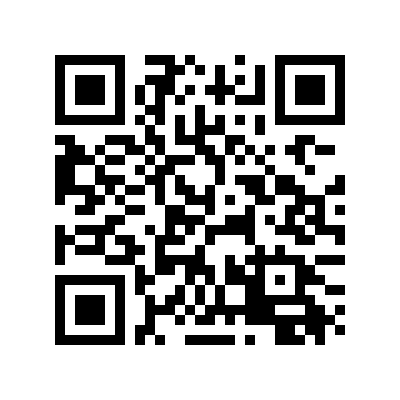

In [3]:
import com.google.zxing.BarcodeFormat
import com.google.zxing.qrcode.QRCodeWriter
import java.awt.image.BufferedImage

import com.google.zxing.client.j2se.MatrixToImageWriter

val writer = QRCodeWriter()
val bitMatrix = writer.encode("https://github.com/adele97/kotlin-notebook-talk", BarcodeFormat.QR_CODE, 400, 400)

MatrixToImageWriter.toBufferedImage(bitMatrix)

So in this helper class is the code I wrote to open a JDBC connection to the postgres database we have set up, run the query we pass in and return the result set as a DataFrame. It will also close the connection when it is done.

In [4]:
import util.Helpers

val helpers = Helpers()

In [5]:
fun queryByTimePeriod(startYear: String, endYear: String) =
    """
SELECT
    pd.*
FROM
    powerlifting_data pd
WHERE
  pd.date BETWEEN '$startYear-01-01' AND '$endYear-12-31'
  AND place != 'NS';
    """

So this query function takes two parameters, startYear and endYear which act as placeholders in our query string. This means that once we run this and have the query saved to the state of the notebook, we then have a template for different queries. So if we were interested in other years, then we can just call this function like any other, really supporting our ability to iterate fast.

And we can run that quickly and load the data we need for our analysis

In [6]:
val query = queryByTimePeriod(startYear = "2025", endYear = "2025")
val data: DataFrame<*> = helpers.fetchResults(query)

data.size()

86113 x 42

Now we’re set up!

So the first thing I like to do when I am taking a look at the data for the first time is run the head command. This command simply prints the first few rows of the data set, I am going to have a look at the first 20.


In [7]:
data.head(20)

name,sex,event,equipment,age,ageclass,birthyearclass,division,bodyweightkg,weightclasskg,squat1kg,squat2kg,squat3kg,squat4kg,best3squatkg,bench1kg,bench2kg,bench3kg,bench4kg,best3benchkg,deadlift1kg,deadlift2kg,deadlift3kg,deadlift4kg,best3deadliftkg,totalkg,place,dots,wilks,glossbrenner,goodlift,tested,country,state,federation,parentfederation,date,meetcountry,meetstate,meettown,meetname,sanctioned
Giovanni Mancinelli,M,SBD,Single-ply,"29,000000",24-34,24-39,Senior,"116,920000",120,"-381,000000","390,000000","400,500000",null,"400,500000","235,000000","245,000000","-252,500000",null,"245,000000","295,000000","310,000000","-330,000000",null,"310,000000","955,500000",1,"553,610000","552,810000","529,460000","93,290000",true,Italy,null,FIPL,IPF,2025-12-20,Italy,null,Lodi Vecchio,24° Coppa Italia di Powerlifting Open...,true
Davide Cecchetti,M,SBD,Single-ply,"23,000000",20-23,19-23,Junior,"90,900000",93,"-317,500000","-317,500000","321,500000",null,"321,500000","235,000000","240,000000","-245,000000",null,"240,000000","265,000000","-280,000000","287,500000",null,"287,500000","849,000000",1,"546,240000","539,290000","516,630000","93,190000",true,Italy,null,FIPL,IPF,2025-12-20,Italy,null,Lodi Vecchio,24° Coppa Italia di Powerlifting Open...,true
Diego Milani,M,SBD,Single-ply,"29,000000",24-34,24-39,Senior,"73,190000",74,"260,000000","-272,500000","-272,500000",null,"260,000000","185,000000","-190,000000","-190,000000",null,"185,000000","275,000000","300,000000","-315,000000",null,"300,000000","745,000000",1,"543,010000","540,120000","522,430000","92,990000",true,Italy,null,FIPL,IPF,2025-12-20,Italy,null,Lodi Vecchio,24° Coppa Italia di Powerlifting Open...,true
Carlo Schembari,M,SBD,Single-ply,"23,000000",20-23,19-23,Junior,"72,560000",74,"-270,000000","270,000000","-285,000000",null,"270,000000","210,000000","216,000000","220,500000",null,"220,500000","230,000000","242,500000","250,000000",null,"250,000000","740,500000",2,"542,830000","540,230000","522,730000","92,950000",true,Italy,null,FIPL,IPF,2025-12-20,Italy,null,Lodi Vecchio,24° Coppa Italia di Powerlifting Open...,true
Giovannino Pinna,M,SBD,Single-ply,"37,500000",35-39,24-39,Senior,"82,320000",83,"275,000000","287,500000","-300,000000",null,"287,500000","215,000000","222,500000","-230,500000",null,"222,500000","260,000000","275,000000","-290,000000",null,"275,000000","785,000000",1,"532,410000","526,570000","506,710000","91,090000",true,Italy,null,FIPL,IPF,2025-12-20,Italy,null,Lodi Vecchio,24° Coppa Italia di Powerlifting Open...,true
Cristian Cortese,M,SBD,Single-ply,"27,500000",24-34,24-39,Senior,"92,550000",93,"300,000000","312,500000","320,000000",null,"320,000000","195,000000","-200,000000","200,000000",null,"200,000000","290,000000","300,000000","-312,500000",null,"300,000000","820,000000",1,"522,950000","516,310000","494,250000","89,150000",true,null,null,FIPL,IPF,2025-12-20,Italy,null,Lodi Vecchio,24° Coppa Italia di Powerlifting Open...,true
Loris Mennillo,M,SBD,Single-ply,"25,500000",24-34,24-39,Senior,"72,490000",74,"245,000000","260,000000","277,500000",null,"277,500000","160,000000","167,500000","-175,000000",null,"167,500000","240,000000","255,000000","262,500000",null,"262,500000","707,500000",2,"518,970000","516,520000","499,810000","88,870000",true,Italy,null,FIPL,IPF,2025-12-20,Italy,null,Lodi Vecchio,24° Coppa Italia di Powerlifting Open...,true
Luca Maggioni,M,SBD,Single-ply,"27,500000",24-34,24-39,Senior,"72,710000",74,"-250,000000","260,000000","-270,000000",null,"260,000000","180,000000","187,500000","192,500000",null,"192,500000","235,000000","247,500000","252,500000",null,"252,500000","705,000000",3,"516,100000","513,560000","496,880000","88,380000",true,null,null,FIPL,IPF,2025-12-20,Italy,null,Lodi Vecchio,24° Coppa Italia di Powerlifting Open...,true
Iury Armi,M,SBD,Single-ply,"25,500000",24-34,24-39,Senior,"72,950000",74,"220,000000","235,000000","245,000000",null,"245,000000","-190,000000","-190,000000","190,000000",null,"190,000000","250,0000

So as we inspect the first 20 rows, we can see that most fields are filled in with values that we’d expect. We have the lifter name, sex, event and equipment all filled in nicely. We see a lot of nulls when we get to squat4kg, but that’s absolutely fine. Fourth attempts are rare and don’t count toward the TotalKg. So for most purposes, you can simply leave these values out.

We see quite a few nulls in the country column, but that’s not unusual. This is the country of the lifter and as per the docs is only included when the lifter country is known. The more important one is meet country which is a mandatory field as per the open powerlifting docs. Nothing really groundbreaking or concrete here, but we have a feel now for how the data looks.

 `Describe` returns a DataFrame with general statistics for all Value Columns.

Interesting columns
- type
- count
- unique

In [8]:
data.describe()

name,type,count,unique,nulls,top,freq,mean,std,min,p25,median,p75,max
name,String,86113,51622,0,Daniel Henson,17,null,null,A Azize Labidine,Elaine Jairusse R Capellan,Katrín Anna Heiðarsdóttir,Patricia Maciejewski,齐禹杰
sex,String,86113,2,0,M,57290,null,null,F,F,M,M,M
event,String,86113,7,0,SBD,70280,null,null,B,SBD,SBD,SBD,SD
equipment,String,86113,3,0,Raw,78185,null,null,Raw,Raw,Raw,Raw,Wraps
age,Double?,86113,167,12581,"22,500000",2876,"29,606865","13,172931","3,500000","20,500000","25,000000","34,500000","90,000000"
ageclass,String?,86113,19,10556,24-34,24133,null,null,13-15,20-23,24-34,24-34,90-999
birthyearclass,String?,86113,8,8757,24-39,27814,null,null,14-18,19-23,24-39,24-39,70-999
division,String,86113,205,0,Open,28190,null,null,College,M-Jr,Masters 4,Open,Ženy Masters
bodyweightkg,Double?,86113,8251,32,"83,000000",318,"82,543761","20,626115","16,950000","67,440000","81,100000","92,680000","221,300000"
weightclasskg,String?,86113,24,917,93,12597,null,null,105,53,74,83,93


Name is actually the identifier in this set, so if another lifter with the same name starts competing they get numbers next to their name. So if we filter here by the name Amanda Lawrence, absolutely phenomenal lifter who’s been dominating the the 84kg class for years now, you see she has the #1 next to her name.

So given that we have about 51,000 unique lifters out of 86,000, we have a non-negligible number doing two or more competitions a year, with Amanda here doing 4.

In [9]:
val amanda = data.filter { it.name.contains("Amanda Lawrence") }

amanda

name,sex,event,equipment,age,ageclass,birthyearclass,division,bodyweightkg,weightclasskg,squat1kg,squat2kg,squat3kg,squat4kg,best3squatkg,bench1kg,bench2kg,bench3kg,bench4kg,best3benchkg,deadlift1kg,deadlift2kg,deadlift3kg,deadlift4kg,best3deadliftkg,totalkg,place,dots,wilks,glossbrenner,goodlift,tested,country,state,federation,parentfederation,date,meetcountry,meetstate,meettown,meetname,sanctioned
Amanda Lawrence #1,F,SBD,Raw,"28,000000",24-34,24-39,FR-O,"88,700000",84,"225,000000","237,500000","245,000000",null,"245,000000","127,500000","135,000000","137,500000",null,"137,500000","235,000000","252,500000","262,500000",null,"262,500000","645,000000",1,"578,770000","560,770000","488,080000","119,380000",true,USA,MN,AMP,IPF,2025-08-16,USA,MN,Minneapolis,Rising Tide,true
Amanda Lawrence #1,F,SBD,Raw,"27,000000",24-34,24-39,FR-O,"83,720000",84,"222,500000","235,000000","242,500000",null,"242,500000","125,000000","132,500000","137,500000",null,"137,500000","230,000000","255,000000","-267,500000",null,"255,000000","635,000000",1,"585,230000","567,200000","495,990000","120,080000",true,USA,MN,AMP,IPF,2025-04-03,USA,GA,College Park,Classic Open Nationals,true
Amanda Lawrence #1,F,SBD,Raw,"28,000000",24-34,24-39,Open,"83,700000",84,"225,000000","237,500000","-247,500000",null,"237,500000","127,500000","132,500000","135,000000",null,"135,000000","242,500000","255,000000","-270,000000",null,"255,000000","627,500000",1,"578,380000","560,570000","490,200000","118,670000",true,USA,null,IPF,IPF,2025-06-08,Germany,null,Chemnitz,World Classic Powerlifting Championships,true
Amanda Lawrence #1,F,SBD,Raw,"27,000000",24-34,24-39,Open,"83,630000",null,"225,000000","240,000000","-250,000000",null,"240,000000","127,500000","135,000000","-140,000000",null,"135,000000","237,500000","255,000000","269,000000",null,"269,000000","644,000000",5,"593,820000","575,550000","503,330000","121,830000",true,USA,null,IPF,IPF,2025-01-26,UK,null,Sheffield,Sheffield Powerlifting Championships,true


So a common place to start when we're doing some data processing is to maybe fill null values, and dataFrame makes that very easy with the `fillNulls` operation. But let me explain why you might not always want to do that.

- null weight class
- negative lifts
- verify total

And doing some basic checks and verifications like this can help us learn the data set, and to take that under consideration when doing our analyses. It does not matter if quirks exist in the data set that we need to spend some time reasoning about, in fact, they are to be expected. What matters is that we are aware of them and make conscious choices in our analysis, so that when asked to defend our conclusions we can.

In [11]:
val bestSquat = "bestSquat"
val bestBench = "bestBench"
val bestDeadlift = "bestDeadlift"
val calculatedTotal = "calculatedTotal"
val totalsMatch = "totalsMatch"

In [12]:
val amandaVerify = amanda
    .add(bestSquat) { listOfNotNull( squat1kg, squat2kg, squat3kg).max() }
    .add(bestBench) { listOfNotNull( bench1kg, bench2kg, bench3kg).max() }
    .add(bestDeadlift) { listOfNotNull( deadlift1kg, deadlift2kg, deadlift3kg).max() }
    .add(calculatedTotal) {
        bestSquat<Double>() + bestBench<Double>() + bestDeadlift<Double>()
    }
    .add(totalsMatch) { kotlin.math.abs(calculatedTotal<Double>() - totalkg) < 1.0 }

amandaVerify.filter { totalsMatch<Boolean>() == false }.rowsCount()

0

In [13]:
val dataVerify = data
    .dropNulls { totalkg } // lifters that didn't post a total, for example no shows
    .add(bestSquat) { listOfNotNull(squat1kg, squat2kg, squat3kg).maxOrNull() } // missed lifts are null
    .add(bestBench) { listOfNotNull(bench1kg, bench2kg, bench3kg).maxOrNull() }
    .add(bestDeadlift) { listOfNotNull(deadlift1kg, deadlift2kg, deadlift3kg).maxOrNull() }
    .dropNulls { bestSquat<Double?>() and bestBench<Double?>() and bestDeadlift<Double?>() }
    .add("calculatedTotal") {
        bestSquat<Double>() + bestBench<Double>() + bestDeadlift<Double>()
    }
    .add(totalsMatch) { kotlin.math.abs(calculatedTotal<Double>() - totalkg!!) < 1.0 }

dataVerify.filter { totalsMatch<Boolean>() == false }.rowsCount()

5

In [14]:
dataVerify
    .select {
        best3squatkg and "bestSquat"<Double>() and best3benchkg and "bestBench"<Double>() and best3deadliftkg and "bestDeadlift"<Double>() and totalkg and "calculatedTotal"<Double>() and "totalsMatch"<Boolean>()
    }
    .filter { "totalsMatch"<Boolean>() == false }

best3squatkg,bestSquat,best3benchkg,bestBench,best3deadliftkg,bestDeadlift,totalkg,calculatedTotal,totalsMatch
null,"-35,000000","30,000000","30,000000","70,000000","70,000000","100,000000","65,000000",false
"192,500000","192,500000","150,000000","150,000000",null,"-227,500000","342,500000","115,000000",false
null,"-115,000000","52,500000","52,500000","142,500000","142,500000","195,000000","80,000000",false
"265,000000","265,000000",null,"-180,000000","320,000000","320,000000","585,000000","405,000000",false
null,"-75,000000","115,000000","115,000000","190,000000","190,000000","305,000000","230,000000",false


In [15]:
data.rowsCount()

86113